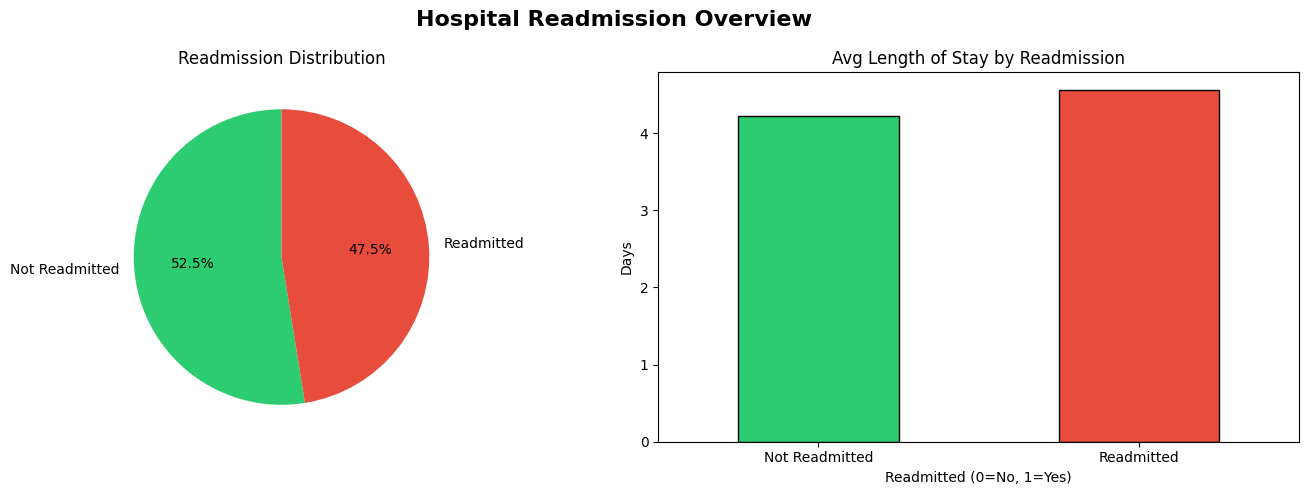

In [0]:
/Volumes/workspace/default/hospital_operations_ai/chart2_patient_flow.pngimport pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

df = spark.table("workspace.default.gold_hospital_features").toPandas()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Hospital Readmission Overview", fontsize=16, fontweight='bold')

# Readmission Distribution
labels = ['Not Readmitted', 'Readmitted']
sizes = df['readmitted_binary'].value_counts().sort_index()
axes[0].pie(sizes, labels=labels, autopct='%1.1f%%',
            colors=['#2ecc71','#e74c3c'], startangle=90)
axes[0].set_title("Readmission Distribution")

# Avg Time in Hospital by Readmission
df.groupby('readmitted_binary')['time_in_hospital'].mean().plot(
    kind='bar', ax=axes[1], color=['#2ecc71','#e74c3c'], edgecolor='black')
axes[1].set_title("Avg Length of Stay by Readmission")
axes[1].set_xlabel("Readmitted (0=No, 1=Yes)")
axes[1].set_ylabel("Days")
axes[1].set_xticklabels(['Not Readmitted','Readmitted'], rotation=0)

plt.tight_layout()
plt.savefig("/Volumes/workspace/default/hospital_operations_ai/chart1_overview.png", dpi=150)
plt.show()

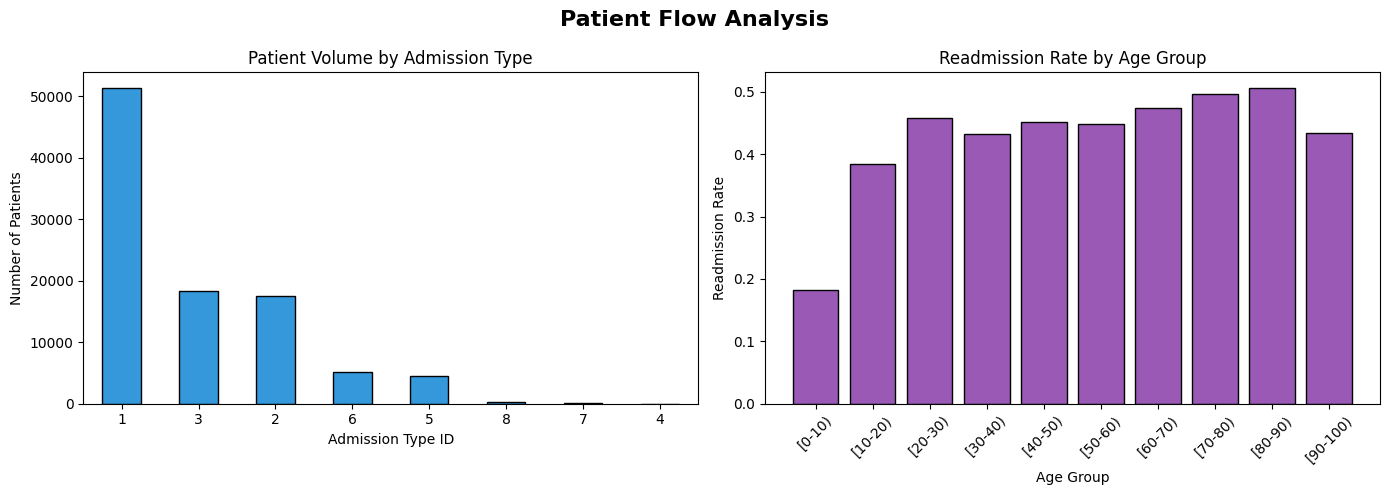

In [0]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Patient Flow Analysis", fontsize=16, fontweight='bold')

# Admissions by Type
df['admission_type_id'].value_counts().plot(
    kind='bar', ax=axes[0], color='#3498db', edgecolor='black')
axes[0].set_title("Patient Volume by Admission Type")
axes[0].set_xlabel("Admission Type ID")
axes[0].set_ylabel("Number of Patients")
axes[0].tick_params(axis='x', rotation=0)

# Age group vs Readmission Rate
age_readmit = df.groupby('age')['readmitted_binary'].mean().reset_index()
age_readmit = age_readmit.sort_values('age')
axes[1].bar(age_readmit['age'], age_readmit['readmitted_binary'],
            color='#9b59b6', edgecolor='black')
axes[1].set_title("Readmission Rate by Age Group")
axes[1].set_xlabel("Age Group")
axes[1].set_ylabel("Readmission Rate")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig("/Volumes/workspace/default/hospital_operations_ai/chart2_patient_flow.png", dpi=150)
plt.show()

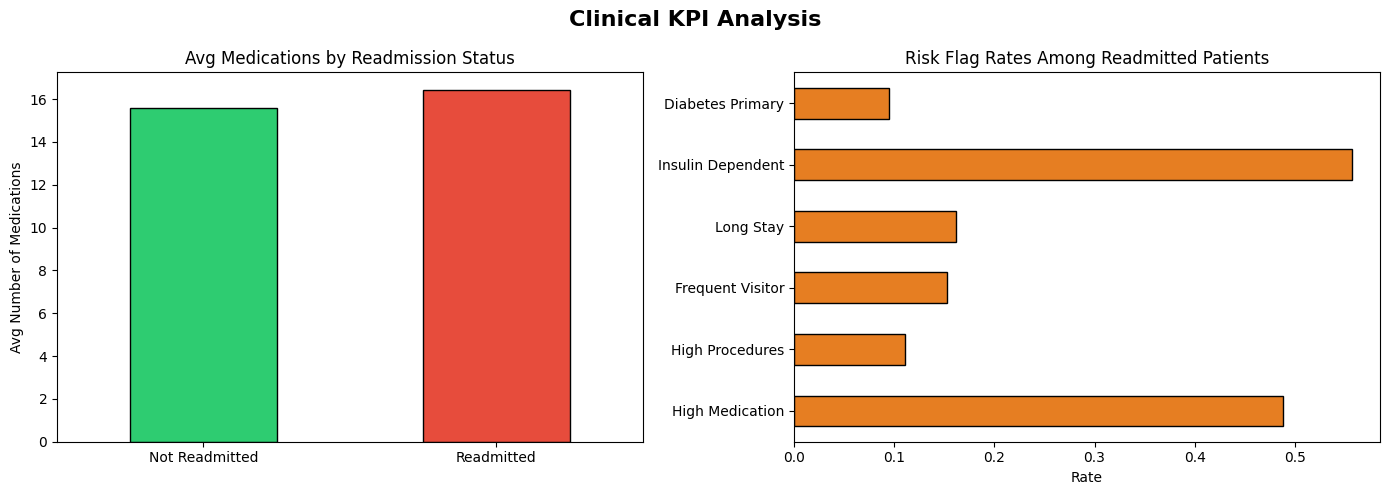

In [0]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Clinical KPI Analysis", fontsize=16, fontweight='bold')

# Medications vs Readmission
df.groupby('readmitted_binary')['num_medications'].mean().plot(
    kind='bar', ax=axes[0], color=['#2ecc71','#e74c3c'], edgecolor='black')
axes[0].set_title("Avg Medications by Readmission Status")
axes[0].set_xlabel("")
axes[0].set_xticklabels(['Not Readmitted','Readmitted'], rotation=0)
axes[0].set_ylabel("Avg Number of Medications")

# High Risk Flags
flags = ['high_medication_flag','high_procedures_flag',
         'frequent_visitor_flag','long_stay_flag',
         'insulin_flag','diabetes_primary_flag']
flag_rates = df[df['readmitted_binary']==1][flags].mean()
flag_rates.plot(kind='barh', ax=axes[1], color='#e67e22', edgecolor='black')
axes[1].set_title("Risk Flag Rates Among Readmitted Patients")
axes[1].set_xlabel("Rate")
axes[1].set_yticklabels([
    'High Medication','High Procedures',
    'Frequent Visitor','Long Stay',
    'Insulin Dependent','Diabetes Primary'], rotation=0)

plt.tight_layout()
plt.savefig("/Volumes/workspace/default/hospital_operations_ai/chart3_kpis.png", dpi=150)
plt.show()

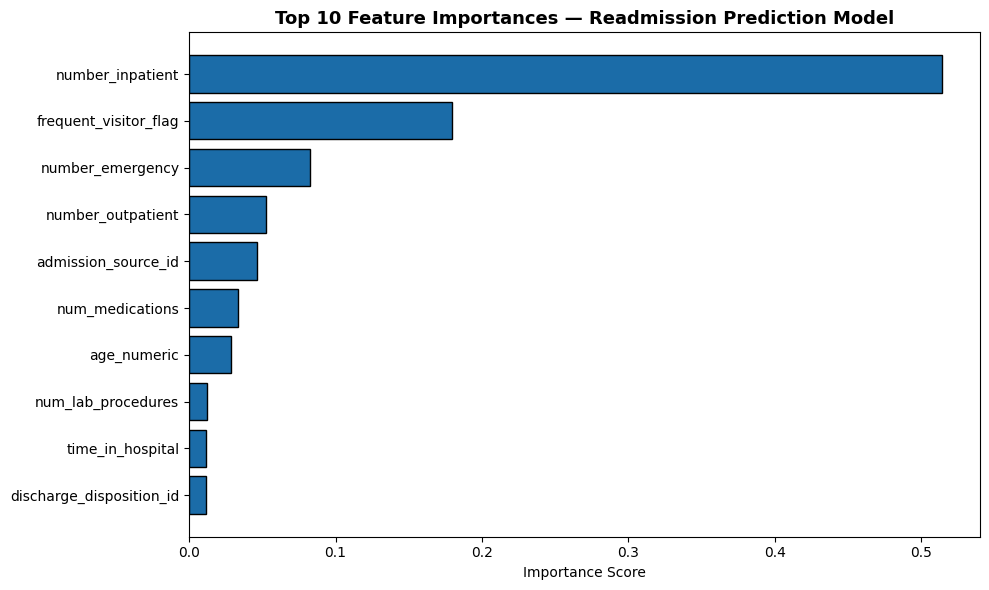

In [0]:
import numpy as np

feature_cols = [
    "age_numeric", "time_in_hospital", "num_lab_procedures",
    "num_procedures", "num_medications", "number_outpatient",
    "number_emergency", "number_inpatient", "admission_type_id",
    "discharge_disposition_id", "admission_source_id",
    "high_medication_flag", "high_procedures_flag",
    "frequent_visitor_flag", "long_stay_flag",
    "insulin_flag", "diabetes_primary_flag"
]

importance_values = [
    0.028739, 0.011573, 0.012007,
    0.006842, 0.033458, 0.052492,
    0.082786, 0.514289, 0.007061,
    0.011302, 0.046586,
    0.007246, 0.000525,
    0.179633, 0.000839,
    0.002152, 0.002468
]

importance_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": importance_values
}).sort_values("importance", ascending=True).tail(10)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(importance_df['feature'], importance_df['importance'],
        color='#1B6CA8', edgecolor='black')
ax.set_title("Top 10 Feature Importances — Readmission Prediction Model",
             fontsize=13, fontweight='bold')
ax.set_xlabel("Importance Score")
plt.tight_layout()
plt.savefig("/Volumes/workspace/default/hospital_operations_ai/chart4_feature_importance.png", dpi=150)
plt.show()

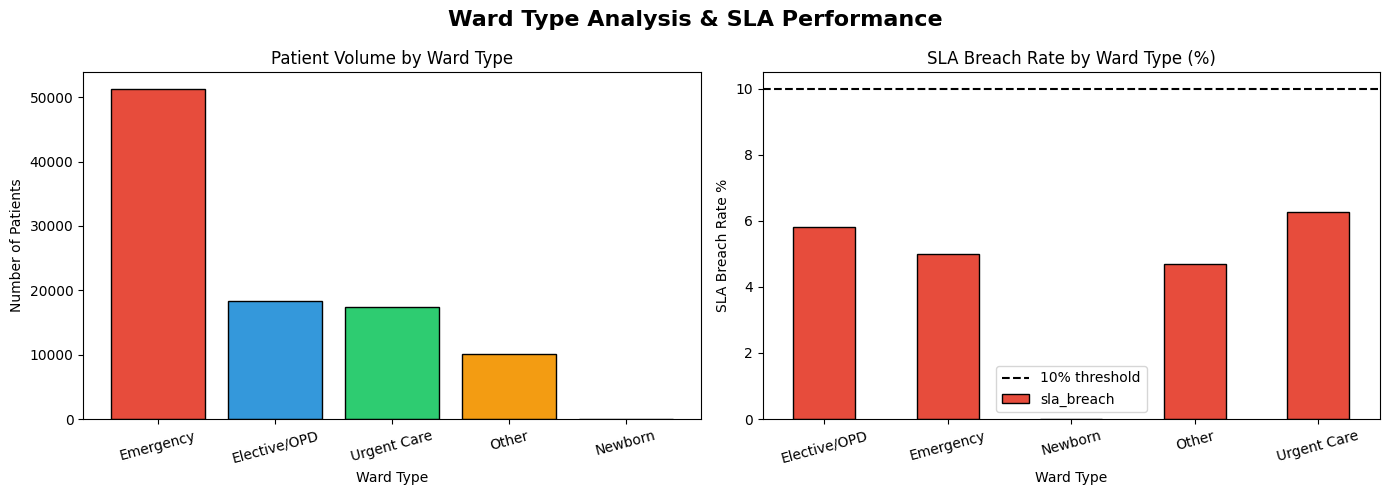

In [0]:
df = spark.table("workspace.default.gold_hospital_features").toPandas()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Ward Type Analysis & SLA Performance", fontsize=16, fontweight='bold')

# Ward Type Patient Volume
ward_counts = df['ward_type'].value_counts()
axes[0].bar(ward_counts.index, ward_counts.values,
            color=['#e74c3c','#3498db','#2ecc71','#f39c12','#9b59b6'],
            edgecolor='black')
axes[0].set_title("Patient Volume by Ward Type")
axes[0].set_xlabel("Ward Type")
axes[0].set_ylabel("Number of Patients")
axes[0].tick_params(axis='x', rotation=15)

# SLA Breach Rate by Ward
sla_by_ward = df.groupby('ward_type')['sla_breach'].mean() * 100
sla_by_ward.plot(kind='bar', ax=axes[1],
                 color='#e74c3c', edgecolor='black')
axes[1].set_title("SLA Breach Rate by Ward Type (%)")
axes[1].set_xlabel("Ward Type")
axes[1].set_ylabel("SLA Breach Rate %")
axes[1].tick_params(axis='x', rotation=15)
axes[1].axhline(y=10, color='black', linestyle='--', label='10% threshold')
axes[1].legend()

plt.tight_layout()
plt.savefig("/Volumes/workspace/default/hospital_operations_ai/chart5_ward_sla.png", dpi=150)
plt.show()

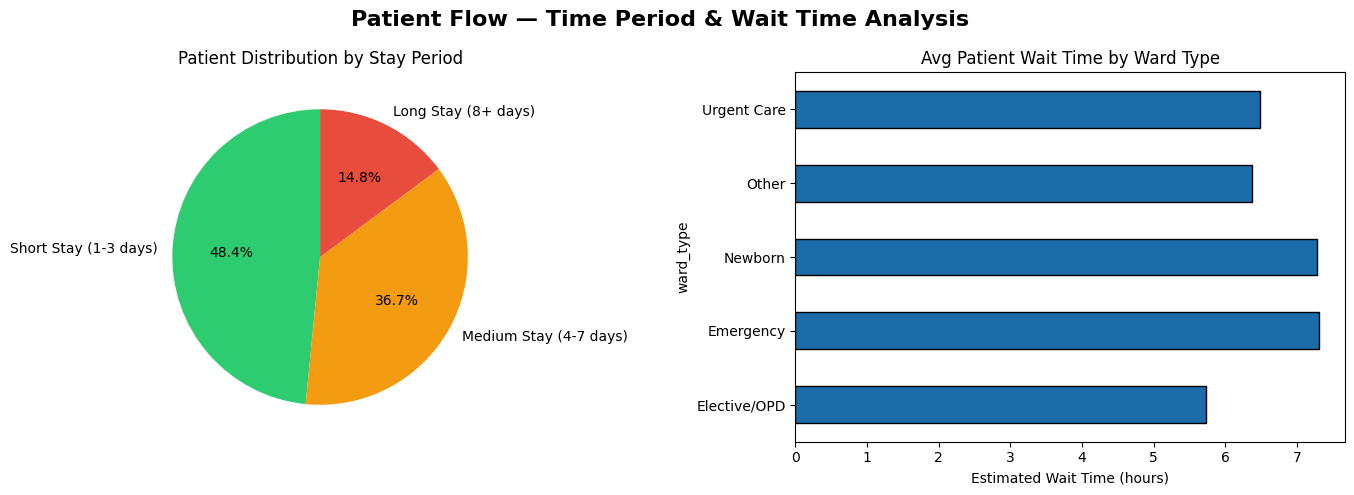

In [0]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Patient Flow — Time Period & Wait Time Analysis", fontsize=16, fontweight='bold')

# Stay Period Distribution
stay_counts = df['stay_period'].value_counts()
colors = ['#2ecc71','#f39c12','#e74c3c']
axes[0].pie(stay_counts.values, labels=stay_counts.index,
            autopct='%1.1f%%', colors=colors, startangle=90)
axes[0].set_title("Patient Distribution by Stay Period")

# Avg Wait Time by Ward
wait_by_ward = df.groupby('ward_type')['estimated_wait_time'].mean()
wait_by_ward.plot(kind='barh', ax=axes[1],
                  color='#1B6CA8', edgecolor='black')
axes[1].set_title("Avg Patient Wait Time by Ward Type")
axes[1].set_xlabel("Estimated Wait Time (hours)")
axes[1].tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig("/Volumes/workspace/default/hospital_operations_ai/chart6_timeperiod_waittime.png", dpi=150)
plt.show()

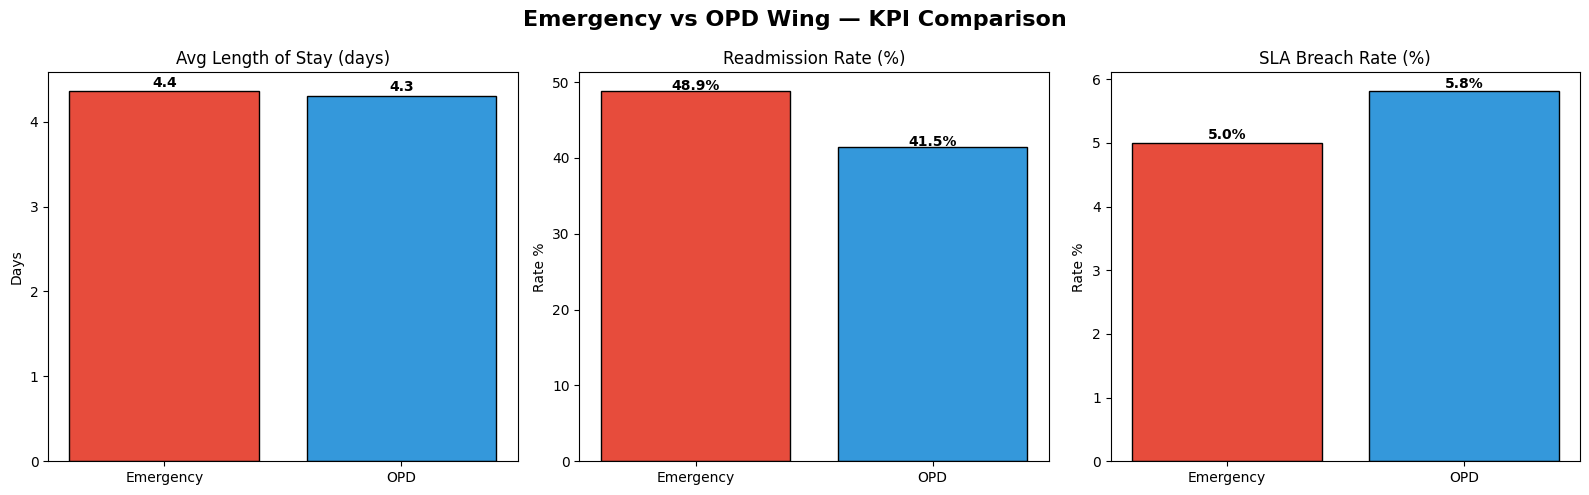

In [0]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Emergency vs OPD Wing — KPI Comparison", fontsize=16, fontweight='bold')

emergency = df[df['ward_type'] == 'Emergency']
opd = df[df['ward_type'] == 'Elective/OPD']

wings = ['Emergency', 'OPD']
colors = ['#e74c3c', '#3498db']

# ALOS Comparison
alos = [emergency['time_in_hospital'].mean(), opd['time_in_hospital'].mean()]
axes[0].bar(wings, alos, color=colors, edgecolor='black')
axes[0].set_title("Avg Length of Stay (days)")
axes[0].set_ylabel("Days")
for i, v in enumerate(alos):
    axes[0].text(i, v + 0.05, f'{v:.1f}', ha='center', fontweight='bold')

# Readmission Rate Comparison
readmit = [emergency['readmitted_binary'].mean()*100,
           opd['readmitted_binary'].mean()*100]
axes[1].bar(wings, readmit, color=colors, edgecolor='black')
axes[1].set_title("Readmission Rate (%)")
axes[1].set_ylabel("Rate %")
for i, v in enumerate(readmit):
    axes[1].text(i, v + 0.05, f'{v:.1f}%', ha='center', fontweight='bold')

# SLA Breach Comparison
sla = [emergency['sla_breach'].mean()*100,
       opd['sla_breach'].mean()*100]
axes[2].bar(wings, sla, color=colors, edgecolor='black')
axes[2].set_title("SLA Breach Rate (%)")
axes[2].set_ylabel("Rate %")
for i, v in enumerate(sla):
    axes[2].text(i, v + 0.05, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig("/Volumes/workspace/default/hospital_operations_ai/chart7_emergency_opd.png", dpi=150)
plt.show()

In [0]:
emergency = df[df['ward_type'] == 'Emergency']
opd = df[df['ward_type'] == 'Elective/OPD']

kpis = {
    "Total Patients":                   len(df),
    "Readmission Rate (%)":             round(df['readmitted_binary'].mean() * 100, 2),
    "Avg Length of Stay (days)":        round(df['time_in_hospital'].mean(), 2),
    "Bed Occupancy — Emergency (%)":    round(len(emergency)/len(df)*100, 2),
    "Bed Occupancy — OPD (%)":          round(len(opd)/len(df)*100, 2),
    "Avg Patient Wait Time (hrs)":      round(df['estimated_wait_time'].mean(), 2),
    "SLA Breach Rate — Overall (%)":    round(df['sla_breach'].mean() * 100, 2),
    "SLA Breach Rate — Emergency (%)":  round(emergency['sla_breach'].mean() * 100, 2),
    "SLA Breach Rate — OPD (%)":        round(opd['sla_breach'].mean() * 100, 2),
    "Peak Load Ward":                   df['ward_type'].value_counts().idxmax(),
    "Avg Medications per Patient":      round(df['num_medications'].mean(), 2),
    "High Risk Patient Rate (%)":       round(df['frequent_visitor_flag'].mean() * 100, 2),
    "Model AUC (Best)":                 0.6742,
    "Model Accuracy (Best)":            0.6287,
}

print("=" * 55)
print("   HOSPITAL OPERATIONS — COMPLETE KPI DASHBOARD")
print("=" * 55)
for k, v in kpis.items():
    print(f"  {k:<40} {v}")
print("=" * 55)
print(f"\nTotal KPIs Tracked: {len(kpis)} ✅")

   HOSPITAL OPERATIONS — COMPLETE KPI DASHBOARD
  Total Patients                           97108
  Readmission Rate (%)                     47.46
  Avg Length of Stay (days)                4.38
  Bed Occupancy — Emergency (%)            52.83
  Bed Occupancy — OPD (%)                  18.86
  Avg Patient Wait Time (hrs)              6.77
  SLA Breach Rate — Overall (%)            5.35
  SLA Breach Rate — Emergency (%)          5.01
  SLA Breach Rate — OPD (%)                5.82
  Peak Load Ward                           Emergency
  Avg Medications per Patient              15.98
  High Risk Patient Rate (%)               9.97
  Model AUC (Best)                         0.6742
  Model Accuracy (Best)                    0.6287

Total KPIs Tracked: 14 ✅
